# Background-correction figure


The example shown here is **Grid G42**, **FB5**, and **Window 13**.

## What this plot is meant to show

The blue points are the original Q3 values.  
The black points are the 30-day filtered means used for the fit.  
The black curve is the fitted background.  
The red points are the corrected residuals.

In simple terms:

\[
\text{Residual Q3} = \text{Raw Q3} - \text{Fitted background}
\]

So the final plot shows both the original signal and what remains after removing the slow seasonal background.

## Background model

The fitted curve uses a linear trend plus an annual sinusoidal term:

\[
Q3_{fit}(t)=a+bt+c\sin\left(\frac{2\pi t}{365.25}+e\right)
\]

I kept the same behaviour as in the original notebook: the fit uses data before `train_end`, and the figure is cropped from `train_start` to `val_end`.

## 1. Settings

Change the file paths, grid, frequency band, or window number here. Nothing else needs to be edited for this figure.

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from scipy import stats
from scipy.optimize import curve_fit

rcParams["font.family"] = "Times New Roman"
plt.style.use("default")

DATA_PATH = r"C:\PROJECT-DEMETER\Demeter_Retrain\Data\Down_Orbits-max-val-location.pkl"
PLOT_DIR = r"C:\PROJECT-DEMETER\Paper1\Plots\BG"

GRID_KEY = "G42"
TARGET_FB = "fb_5"
TARGET_WINDOW_INDEX = 0

WINDOW_SIZE = "30D"
TRAIN_MONTHS = 30
VAL_MONTHS = 3
STRIDE_MONTHS = 3

os.makedirs(PLOT_DIR, exist_ok=True)

## 2. Functions used for the figure

These functions do only four things: make the rolling window, collect the Q3 values, fit the background, and draw the final figure.

In [2]:
def generate_windows(start_date, end_date, train_months, val_months, stride_months):
    windows = []
    current = pd.to_datetime(start_date)
    end_date = pd.to_datetime(end_date)

    while current + pd.DateOffset(months=train_months + val_months) < end_date:
        train_start = current
        train_end = current + pd.DateOffset(months=train_months)
        val_end = train_end + pd.DateOffset(months=val_months)

        windows.append({
            "train_start": train_start,
            "train_end": train_end,
            "val_end": val_end,
        })

        current = current + pd.DateOffset(months=stride_months)

    return windows


def seasonal_background(t, a, b, c, d, e):
    return a + b * t + c * np.sin((2 * np.pi * t) / d + e)


def filtered_mean_and_error(group, column):
    mean_value = group[column].mean()
    lower, upper = stats.norm.interval(
        0.90,
        loc=mean_value,
        scale=np.std(group[column]),
    )

    filtered = group[
        (group[column] >= lower) &
        (group[column] <= upper)
    ]

    if filtered.empty:
        filtered = group

    return (
        filtered[column].mean(),
        np.std(filtered[column]) / np.sqrt(len(filtered[column])),
    )


def make_band_dataframe(data, grid_key, fb, val_end):
    q3_column = f"Q3_{fb}"
    rows = []

    for grid_data in data[grid_key]:
        if fb in grid_data:
            rows.append({
                "datetime": pd.to_datetime(grid_data[fb]["datetime"]),
                q3_column: grid_data[fb]["Q3"],
            })

    df = pd.DataFrame(rows).set_index("datetime").sort_index()
    return df[df.index < val_end], q3_column


def fit_background(df_raw, column, train_end, window_size):
    df_train = df_raw[df_raw.index < train_end]

    rows = []
    for _, group in df_train.resample(window_size):
        group = group.dropna(subset=[column])

        if len(group) >= 2:
            mean_value, error_value = filtered_mean_and_error(group, column)
            rows.append({
                "window": group.index[0],
                f"mean_{column}": mean_value,
                f"std_{column}": error_value,
            })

    df_resampled = pd.DataFrame(rows).dropna()
    df_resampled_plot = df_resampled.set_index("window").copy()

    time_fit = pd.to_datetime(df_resampled["window"]).to_numpy().astype("datetime64[s]").astype(int)
    t_fit = (time_fit - time_fit[0]) / (24 * 3600)

    q3_fit = df_resampled[f"mean_{column}"].to_numpy()
    q3_error = df_resampled[f"std_{column}"].to_numpy()
    q3_error = np.where(q3_error == 0, 1e-8, q3_error)

    initial_guess = [
        np.mean(q3_fit),
        (q3_fit[-1] - q3_fit[0]) / len(q3_fit),
        (q3_fit.max() - q3_fit.min()) / 2,
        365.25,
        np.pi,
    ]

    popt, _ = curve_fit(
        seasonal_background,
        t_fit,
        q3_fit,
        p0=initial_guess,
        sigma=q3_error,
        bounds=(
            [-np.inf, -np.inf, 0, 365.25, -np.inf],
            [np.inf, np.inf, 3, 365.2500001, np.inf],
        ),
        maxfev=650000,
    )

    time_all = pd.to_datetime(df_raw.index).to_numpy().astype("datetime64[s]").astype(int)
    t_all = (time_all - time_all[0]) / (24 * 3600)

    df_out = df_raw.copy()
    df_out[f"fit_{column}"] = seasonal_background(t_all, *popt)
    df_out[f"Res_{column}"] = df_out[column] - df_out[f"fit_{column}"]
    df_resampled_plot[f"fit_c_{column}"] = seasonal_background(t_fit, *popt)

    return df_out, df_resampled_plot


def plot_background_correction(df, df_resampled, column, grid_key, fb, train_start, val_end, save_path):
    df = df[(df.index >= train_start) & (df.index < val_end)]
    df_resampled = df_resampled[
        (df_resampled.index >= train_start) &
        (df_resampled.index < val_end)
    ]

    fig, ax1 = plt.subplots(figsize=(12, 5.5))

    ax1.scatter(df.index, df[column], s=22, alpha=0.5, label="Raw data")
    ax1.scatter(
        df_resampled.index,
        df_resampled[f"mean_{column}"],
        s=35,
        color="black",
        alpha=0.9,
        label="Resampled data",
    )
    ax1.plot(
        df_resampled.index,
        df_resampled[f"fit_c_{column}"],
        color="black",
        lw=2,
        label="Fitted Curve",
    )

    ax1.set_xlabel("Time", fontsize=22)
    ax1.set_ylabel("Raw Q3", fontsize=22)
    ax1.set_ylim(-3.5, 6)
    ax1.tick_params(axis="both", labelsize=15)
    ax1.grid(True, linestyle="--", alpha=0.4)

    ax2 = ax1.twinx()
    ax2.scatter(
        df.index,
        df[f"Res_{column}"],
        s=16,
        alpha=0.6,
        color="red",
        label="Residuals",
    )
    ax2.set_ylabel("Residual Q3", fontsize=22)
    ax2.set_ylim(-3.5, 6)
    ax2.tick_params(axis="y", labelsize=15)
    ax2.axhline(0, linestyle="--", color="gray", linewidth=1.5)

    handles_1, labels_1 = ax1.get_legend_handles_labels()
    handles_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(
        handles_1 + handles_2,
        labels_1 + labels_2,
        loc="upper left",
        fontsize=19,
        frameon=True,
    )

    plt.title(f"Grid: {grid_key} - {fb.replace('fb_', 'FB')}", fontsize=23)
    # plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

## 3. Make the final plot

Running this cell produces and saves the final background-correction figure.

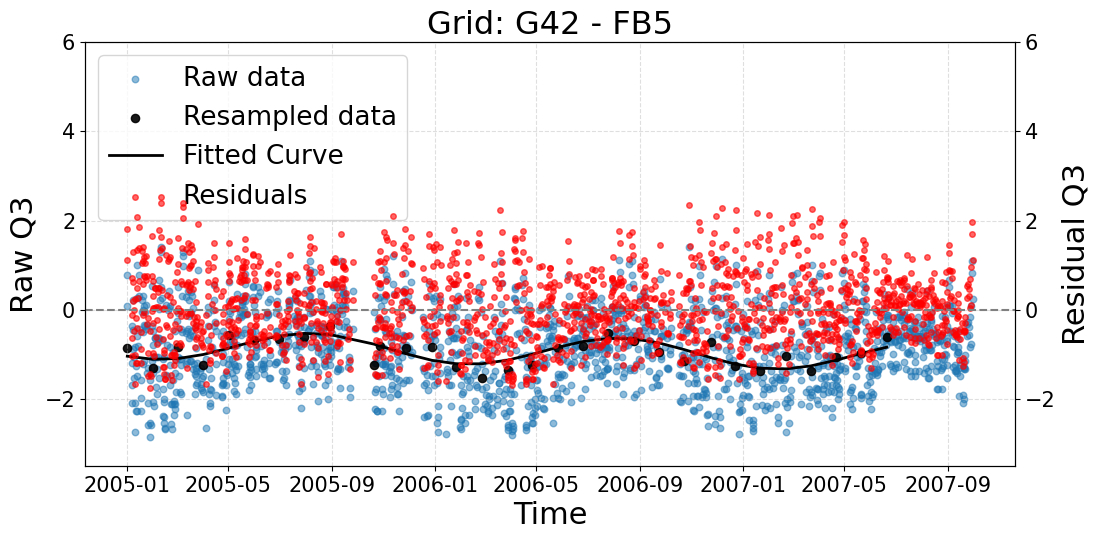

In [3]:
data = pd.read_pickle(DATA_PATH)

windows = generate_windows(
    start_date="2005-01-01 00:00:00",
    end_date="2011-01-02 00:00:00",
    train_months=TRAIN_MONTHS,
    val_months=VAL_MONTHS,
    stride_months=STRIDE_MONTHS,
)

selected_window = windows[TARGET_WINDOW_INDEX]

df_raw, q3_column = make_band_dataframe(
    data=data,
    grid_key=GRID_KEY,
    fb=TARGET_FB,
    val_end=selected_window["val_end"],
)

df_corrected, df_resampled = fit_background(
    df_raw=df_raw,
    column=q3_column,
    train_end=selected_window["train_end"],
    window_size=WINDOW_SIZE,
)

save_path = os.path.join(
    PLOT_DIR,
    f"W{TARGET_WINDOW_INDEX}_{TARGET_FB}_{GRID_KEY}_{WINDOW_SIZE}_dual.png",
)

plot_background_correction(
    df=df_corrected,
    df_resampled=df_resampled,
    column=q3_column,
    grid_key=GRID_KEY,
    fb=TARGET_FB,
    train_start=selected_window["train_start"],
    val_end=selected_window["val_end"],
    save_path=save_path,
)